In [66]:
import torch
import torch.nn as nn
import numpy as np
import pandas as pd
import random
import networkx as nx
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
import pickle
import copy
import os
from sklearn.neighbors import NearestNeighbors


In [67]:
# =========================
# GCN LAYER (D^{-1/2} A_tilde D^{-1/2})
# =========================
class GCNLayer(nn.Module):
    def __init__(self, in_dim, out_dim):
        super().__init__()
        self.W = nn.Linear(in_dim, out_dim)

    def forward(self, X, A):
        # X: (batch, nodes, features)
        # A: (nodes, nodes) — không tự loop trong buffer; cộng I ở đây
        n = A.size(0)
        I = torch.eye(n, device=A.device, dtype=A.dtype)
        A_tilde = A + I
        deg = A_tilde.sum(dim=1).clamp(min=1e-12)
        d_inv_sqrt = torch.pow(deg, -0.5)
        D_inv_sqrt = torch.diag(d_inv_sqrt)
        A_norm = D_inv_sqrt @ A_tilde @ D_inv_sqrt
        out = self.W(A_norm @ X)
        return torch.relu(out)


# =========================
# GCN + LSTM (LSTM trên vector trạng thái cả đồ thị mỗi bước thời gian)
# =========================
class GCN_LSTM(nn.Module):
    """
    Mỗi bước thời gian: GCN trộn láng giềng không gian.
    Chuỗi thời gian: LSTM nhận (nodes * gcn_hidden) — toàn bộ nút sau GCN,
    giữ phụ thuộc không gian trong chuỗi thời gian (không tách LSTM theo từng trạm).
    """

    def __init__(
        self,
        A,
        num_nodes,
        in_features,
        hidden_dim=64,
        lstm_hidden=128,
        lstm_num_layers=2,
        dropout_p=0.3,
    ):
        super().__init__()
        self.num_nodes = num_nodes
        self.gcn_hidden = hidden_dim

        self.register_buffer("A", torch.tensor(A, dtype=torch.float32))
        self.gcn = GCNLayer(in_features, hidden_dim)

        # Dropout sau GCN để giảm overfit vào nhiễu.
        self.dropout_gcn = nn.Dropout(dropout_p)

        # LSTM dùng num_layers=2 để dropout bên trong LSTM có hiệu lực.
        self.lstm = nn.LSTM(
            input_size=hidden_dim,
            hidden_size=lstm_hidden,
            num_layers=lstm_num_layers,
            dropout=dropout_p if lstm_num_layers > 1 else 0.0,
            batch_first=True,
            bidirectional=False,
        )

        # Dropout trên biểu diễn trước FC.
        self.dropout_lstm = nn.Dropout(dropout_p)
        self.fc = nn.Linear(lstm_hidden, 1)

    def forward(self, x, target_idx=None):
        """
        x: (batch, time, nodes, features)
        target_idx:
          - None: trả về dự đoán cho tất cả nodes => (batch, nodes)
          - int: chỉ trả về dự đoán 1 node mục tiêu => (batch,)
        """
        batch, time_steps, nodes, _ = x.shape

        # 1) GCN cho từng bước thời gian: (batch, time, nodes, hidden)
        gcn_out = []
        for t in range(time_steps):
            xt = x[:, t, :, :]  # (batch, nodes, features)
            ht = self.gcn(xt, self.A)  # (batch, nodes, hidden)
            ht = self.dropout_gcn(ht)
            gcn_out.append(ht)
        gcn_seq = torch.stack(gcn_out, dim=1)  # (batch, time, nodes, hidden)

        # 2) LSTM theo từng node (mỗi node có chuỗi thời gian, nhưng đầu vào đã được GCN trộn k-lân-cận)
        #    (batch, nodes, time, hidden) -> (batch*nodes, time, hidden)
        gcn_seq = gcn_seq.permute(0, 2, 1, 3).contiguous()
        gcn_flat = gcn_seq.view(batch * nodes, time_steps, self.gcn_hidden)

        lstm_out, _ = self.lstm(gcn_flat)  # (batch*nodes, time, lstm_hidden)
        last_step = lstm_out[:, -1, :]  # (batch*nodes, lstm_hidden)
        last_step = self.dropout_lstm(last_step)

        # 3) Dự đoán cho từng node rồi chọn 1 node nếu cần
        pred_all = self.fc(last_step).view(batch, nodes)  # (batch, nodes)

        if target_idx is None:
            return pred_all
        return pred_all[:, target_idx]


class EarlyStopping:
    def __init__(self, patience=8, min_delta=0):
        self.patience = patience
        self.min_delta = min_delta
        self.counter = 0
        self.best_loss = None
        self.early_stop = False
        self.best_state = None

    def __call__(self, val_loss, model):
        if self.best_loss is None:
            self.best_loss = val_loss
            self.best_state = copy.deepcopy(model.state_dict())
        elif val_loss > self.best_loss - self.min_delta:
            self.counter += 1
            if self.counter >= self.patience:
                self.early_stop = True
        else:
            self.best_loss = val_loss
            self.best_state = copy.deepcopy(model.state_dict())
            self.counter = 0

In [68]:
def visualize_spatial_graph(A, node_to_idx, df_long):
    print("\n   => Đang mở biểu đồ trực quan Bản đồ Spatial Graph...")
    G = nx.Graph()
    nodes = list(node_to_idx.keys())

    coords = df_long.groupby("SCATS_ID")[["lat", "lon"]].first().loc[nodes]

    pos = {}
    for i, node in enumerate(nodes):
        G.add_node(i, label=str(node))
        pos[i] = (coords.iloc[i]["lon"], coords.iloc[i]["lat"])

    N = len(nodes)
    for i in range(N):
        for j in range(i + 1, N):
            if A[i, j] > 0:
                G.add_edge(i, j, weight=A[i, j])

    plt.figure(figsize=(12, 8))
    nx.draw(
        G,
        pos,
        with_labels=True,
        node_size=300,
        node_color="lightcoral",
        font_size=8,
        font_weight="bold",
        edge_color="gray",
        alpha=0.9,
    )
    
    plt.title("Spatial Graph of SCATS Intersections (KNN Adjacency Matrix)")
    plt.xlabel("Longitude")
    plt.ylabel("Latitude")
    plt.axis("on")
    plt.show()

In [69]:
def build_adjacency_matrix(df_long, k=3):
    """
    Build KNN-based adjacency matrix from traffic data.
    
    Args:
        df_long: DataFrame with columns SCATS_ID, lat, lon
        k: Number of nearest neighbors (excluding self)
    
    Returns:
        A: Adjacency matrix (N x N)
        node_to_idx: Mapping from SCATS_ID to index
    """
    # Get unique stations and their coordinates
    nodes = sorted(df_long['SCATS_ID'].unique())
    node_to_idx = {n: i for i, n in enumerate(nodes)}
    
    coords = df_long.groupby("SCATS_ID")[["lat", "lon"]].first().loc[nodes]
    coords_array = coords[["lat", "lon"]].values
    
    N = len(nodes)
    A = np.zeros((N, N))
    
    # Build KNN adjacency matrix
    nbrs = NearestNeighbors(n_neighbors=k+1, algorithm='ball_tree').fit(coords_array)
    distances, indices = nbrs.kneighbors(coords_array)
    
    for i in range(N):
        for idx in indices[i][1:]:  # Skip self (index 0)
            A[i, idx] = 1.0
    
    return A, node_to_idx

In [70]:
def build_tensor(df_long, node_to_idx, feature_cols):
    """
    Create Spatio-Temporal Tensor structure: (T_Time, N_Node, F_Feature)
    
    Args:
        df_long: Long-format DataFrame with Timestamp, SCATS_ID, and feature columns
        node_to_idx: Dictionary mapping SCATS_ID to node indices
        feature_cols: List of feature column names to include
    
    Returns:
        tensor: 3D NumPy array of shape (T, N, F) where:
            T = number of timestamps, N = number of nodes, F = number of features
    """
    times = sorted(df_long['Timestamp'].unique())
    nodes = list(node_to_idx.keys())

    T = len(times)
    N = len(nodes)
    F = len(feature_cols)

    tensor = np.zeros((T, N, F))
    
    # Optimize by indexing and grouping for faster iteration
    df_indexed = df_long.set_index(['Timestamp', 'SCATS_ID'])[feature_cols]
    
    for t_idx, t in enumerate(times):
        try:
            # Get data at timestamp t for all nodes
            df_t = df_indexed.loc[t]
            for node in df_t.index:
                n_idx = node_to_idx[node]
                tensor[t_idx, n_idx, :] = df_t.loc[node].values
        except KeyError:
            continue
            
    return tensor

In [71]:
def create_st_sequences(tensor, seq_len=96):
    """
    Tạo cửa sổ trượt tịnh tiến theo KHUNG THỜI GIAN trên TẤT CẢ các trạm.
    Đầu vào: tensor (T, N, F)
    Đầu ra: 
       X shape (mẫu, thời_điểm, trạm, features)
       y shape (mẫu, trạm) - lưu lượng xe của trạm (giả định ở cột 0) ở bước tiếp theo
    """
    X, y = [], []
    T = tensor.shape[0]
    
    for i in range(T - seq_len):
        X.append(tensor[i : i + seq_len])
        # Dự đoán lưu lượng (feature 0) cho CẢ KHỐI CÁC TRẠM
        y.append(tensor[i + seq_len, :, 0])  
        
    return np.array(X), np.array(y)

T, N, F_dim = tensor.shape
train_end_t = int(T * 0.7)

tensor_2d = tensor.reshape(-1, F_dim)
train_2d = tensor[:train_end_t].reshape(-1, F_dim)

scaler_gcn = MinMaxScaler()
scaler_gcn.fit(train_2d)

tensor_scaled = scaler_gcn.transform(tensor_2d).reshape(T, N, F_dim)
print(f"Tensor scaled. Shape: {tensor_scaled.shape}")

# --- Create sequences from scaled tensor ---
X_gcn, y_gcn = create_st_sequences(tensor_scaled, seq_len=96)
print(f"X_gcn shape: {X_gcn.shape}  (samples, seq_len, nodes, features)")
print(f"y_gcn shape: {y_gcn.shape}  (samples, nodes)")

Tensor scaled. Shape: (2976, 40, 13)
X_gcn shape: (2880, 96, 40, 13)  (samples, seq_len, nodes, features)
y_gcn shape: (2880, 40)  (samples, nodes)


In [72]:
print("1. Loading preprocessed data from data_preprocessing notebook...")

with open('../data/preprocessed/preprocessed_data_custom_gcn_lstm.pkl', 'rb') as f:
    data_dict = pickle.load(f)

X_train = data_dict['X_train']
y_train = data_dict['y_train']
X_val = data_dict['X_val']

y_val = data_dict['y_val']
X_test = data_dict['X_test']
y_test = data_dict['y_test']
df_long = data_dict['df_long']

A = data_dict['A']
node_to_idx = data_dict['node_to_idx']

print("Data loaded successfully!")
print(f"Train: X_train {X_train.shape}, y_train {y_train.shape}")
print(f"Val: X_val {X_val.shape}, y_val {y_val.shape}")
print(f"Test: X_test {X_test.shape}, y_test {y_test.shape}") 
print(f"Adjacency matrix shape: {A.shape}")
print(f"Number of nodes: {len(node_to_idx)}")

1. Loading preprocessed data from data_preprocessing notebook...
Data loaded successfully!
Train: X_train (2015, 96, 40, 13), y_train (2015, 40)
Val: X_val (433, 96, 40, 13), y_val (433, 40)
Test: X_test (432, 96, 40, 13), y_test (432, 40)
Adjacency matrix shape: (40, 40)
Number of nodes: 40


2. Đang xây dựng Ma Trận Kề (Adjacency Matrix) bằng thuật toán KNN...
   => Cấu trúc không gian: 40 Trạm SCATS

   => Đang mở biểu đồ trực quan Bản đồ Spatial Graph...


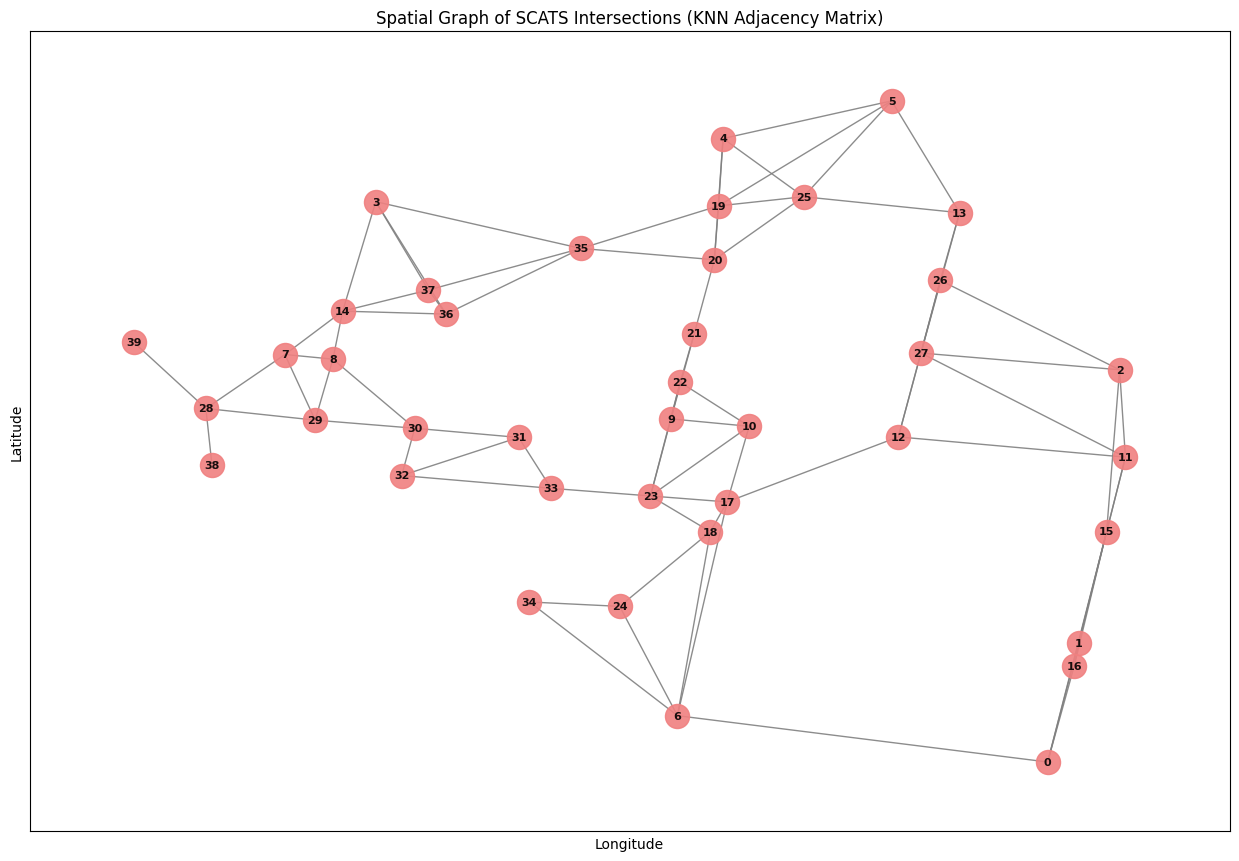

In [73]:
print("2. Đang xây dựng Ma Trận Kề (Adjacency Matrix) bằng thuật toán KNN...")
A, node_to_idx = build_adjacency_matrix(df_long, k=4)
num_nodes = len(node_to_idx)
print(f"   => Cấu trúc không gian: {num_nodes} Trạm SCATS")

visualize_spatial_graph(A, node_to_idx, df_long)

# Cột 0 trong tensor = Traffic_Volume (target); các cột còn lại = đặc trưng X
feature_cols = [
        "Traffic_Volume",
        "hour_sin",
        "hour_cos",
        "slot_sin",
        "slot_cos",
        "dow_sin",
        "dow_cos",
        "is_weekend",
        "is_rush_hour",
        "is_night",
        "traffic_lag_1",
        "traffic_lag_4",
        "traffic_lag_96",
]
x_feature_cols = [c for c in feature_cols if c != "Traffic_Volume"]
num_features = len(feature_cols)

In [74]:
print("\n3. Chuẩn hóa: scaler_y (Traffic_Volume) và scaler_X (đặc trưng) tách biệt")
scaler_y = MinMaxScaler(feature_range=(0, 1))
scaler_x = MinMaxScaler(feature_range=(0, 1))

df_long["Traffic_Volume_Original"] = df_long["Traffic_Volume"].copy()

scaler_y.fit(df_long[["Traffic_Volume"]])
df_long["Traffic_Volume"] = scaler_y.transform(df_long[["Traffic_Volume"]]).ravel()

scaler_x.fit(df_long[x_feature_cols])
df_long[x_feature_cols] = scaler_x.transform(df_long[x_feature_cols])


3. Chuẩn hóa: scaler_y (Traffic_Volume) và scaler_X (đặc trưng) tách biệt


In [75]:
print("4. Đang tạo cấu trúc khối Tensor Không-Thời Gian (T, N, F)...")
tensor = build_tensor(df_long, node_to_idx, feature_cols)
print(f"   => Kích thước Tensor (Time(T), Nodes(N), Features(F)): {tensor.shape}")


4. Đang tạo cấu trúc khối Tensor Không-Thời Gian (T, N, F)...
   => Kích thước Tensor (Time(T), Nodes(N), Features(F)): (2976, 40, 13)


In [76]:
seq_length = 96
print(f"5. Cắt Sliding Window (Seq = {seq_length})...")
X, y = create_st_sequences(tensor, seq_len=seq_length)

5. Cắt Sliding Window (Seq = 96)...


In [77]:
print("6. Phân tách tập Train/Val/Test tuần tự (70-15-15)...")
train_size = int(len(X) * 0.7)
val_size = int(len(X) * 0.15)

X_train, y_train = X[:train_size], y[:train_size]
X_val, y_val = X[train_size : train_size + val_size], y[train_size : train_size + val_size]
X_test, y_test = X[train_size + val_size :], y[train_size + val_size :]

6. Phân tách tập Train/Val/Test tuần tự (70-15-15)...


In [78]:
print("\n7. PyTorch Setup (Device, Optimizer, Data Loaders)")
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"   => Thiết bị triển khai Train: {device}")

hidden_dim = 64
lstm_hidden = 128
dropout_p = 0.35
model = GCN_LSTM(
        A,
        num_nodes=num_nodes,
        in_features=num_features,
        hidden_dim=hidden_dim,
        lstm_hidden=lstm_hidden,
        lstm_num_layers=2,
        dropout_p=dropout_p,
).to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)
loss_fn = nn.MSELoss()

X_train_t = torch.tensor(X_train, dtype=torch.float32).to(device)
y_train_t = torch.tensor(y_train, dtype=torch.float32).to(device)
X_val_t = torch.tensor(X_val, dtype=torch.float32).to(device)
y_val_t = torch.tensor(y_val, dtype=torch.float32).to(device)



7. PyTorch Setup (Device, Optimizer, Data Loaders)
   => Thiết bị triển khai Train: cpu


In [79]:
epochs = 50
print(f"8. Bắt đầu quá trình Loop Huấn luyện {epochs} Epochs Tích hợp Early Stopping...")

batch_size = 32
train_dataset = torch.utils.data.TensorDataset(X_train_t, y_train_t)
train_loader = torch.utils.data.DataLoader(train_dataset, batch_size=batch_size, shuffle=False)

train_losses = []
val_losses = []

early_stopper = EarlyStopping(patience=8, min_delta=0.0001)

# Chỉ predict 1 location (1 node) nhưng vẫn dùng GCN để lấy thông tin từ các node lân cận (KNN k-hop).
# Bạn có thể đổi chỉ số này nếu muốn dự báo trạm khác.
target_node_idx = 0
if target_node_idx >= num_nodes:
    raise ValueError(f"target_node_idx={target_node_idx} vượt num_nodes={num_nodes}")

for epoch in range(epochs):
    model.train()
    total_loss = 0

    for batch_x, batch_y in train_loader:
            optimizer.zero_grad()
            pred = model(batch_x, target_idx=target_node_idx)  # (batch,)
            target = batch_y[:, target_node_idx]  # (batch,)
            loss = loss_fn(pred, target)
            loss.backward()
            optimizer.step()
            total_loss += loss.item()

    epoch_train_loss = total_loss / len(train_loader)

    model.eval()
    with torch.no_grad():
            val_pred = model(X_val_t, target_idx=target_node_idx)  # (val_batch,)
            val_target = y_val_t[:, target_node_idx]  # (val_batch,)
            epoch_val_loss = loss_fn(val_pred, val_target).item()

    train_losses.append(epoch_train_loss)
    val_losses.append(epoch_val_loss)

    print(
            f"   ► Epoch {epoch+1:02d}/{epochs} | Train Loss (MSE): {epoch_train_loss:.4f} | "
            f"Validation Loss (MSE): {epoch_val_loss:.4f}"
        )

    early_stopper(epoch_val_loss, model)
    if early_stopper.early_stop:
            print(f"   => Early Stopping dừng huấn luyện ở Epoch {epoch+1}.")
            break

    model.load_state_dict(early_stopper.best_state)
    print("   => Khôi phục lại Best Weights trong lịch sử Model.")

8. Bắt đầu quá trình Loop Huấn luyện 50 Epochs Tích hợp Early Stopping...
   ► Epoch 01/50 | Train Loss (MSE): 0.0618 | Validation Loss (MSE): 0.0253
   => Khôi phục lại Best Weights trong lịch sử Model.
   ► Epoch 02/50 | Train Loss (MSE): 0.0224 | Validation Loss (MSE): 0.0098
   => Khôi phục lại Best Weights trong lịch sử Model.
   ► Epoch 03/50 | Train Loss (MSE): 0.0136 | Validation Loss (MSE): 0.0084
   => Khôi phục lại Best Weights trong lịch sử Model.
   ► Epoch 04/50 | Train Loss (MSE): 0.0100 | Validation Loss (MSE): 0.0118
   => Khôi phục lại Best Weights trong lịch sử Model.
   ► Epoch 05/50 | Train Loss (MSE): 0.0100 | Validation Loss (MSE): 0.0079
   => Khôi phục lại Best Weights trong lịch sử Model.
   ► Epoch 06/50 | Train Loss (MSE): 0.0099 | Validation Loss (MSE): 0.0303
   => Khôi phục lại Best Weights trong lịch sử Model.
   ► Epoch 07/50 | Train Loss (MSE): 0.0089 | Validation Loss (MSE): 0.0152
   => Khôi phục lại Best Weights trong lịch sử Model.
   ► Epoch 08/50


9. Vẽ đường cong Huấn Luyện (Learning Curve)...


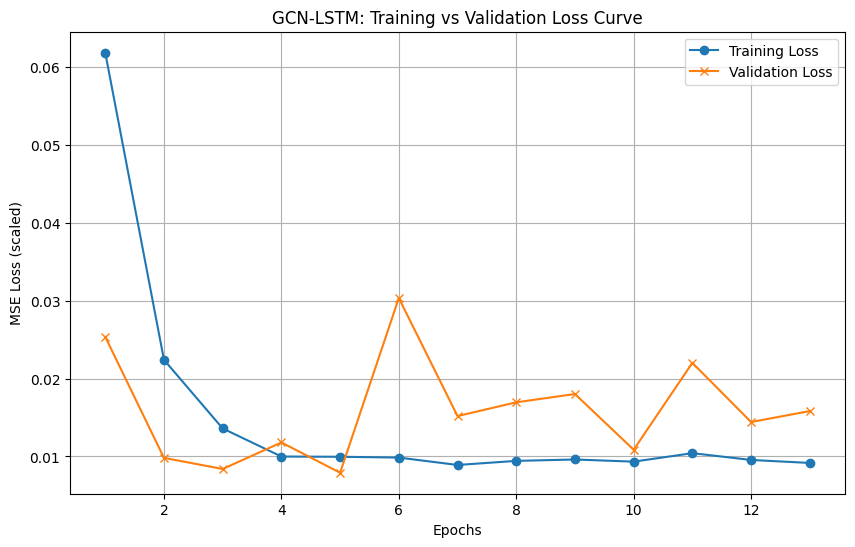

In [80]:
print("\n9. Vẽ đường cong Huấn Luyện (Learning Curve)...")
plt.figure(figsize=(10, 6))
plt.plot(range(1, len(train_losses) + 1), train_losses, label="Training Loss", marker="o")
plt.plot(range(1, len(val_losses) + 1), val_losses, label="Validation Loss", marker="x")
plt.title("GCN-LSTM: Training vs Validation Loss Curve")
plt.xlabel("Epochs")
plt.ylabel("MSE Loss (scaled)")
plt.legend()
plt.grid()
plt.show()


10. Evaluation với Test Set & Forecasting Visualization...
   => Test MSE (thang đo gốc — xe/15 phút) @ node 0: 24341.8614
   => Test RMSE (thang đo gốc — xe/15 phút) @ node 0: 156.0188


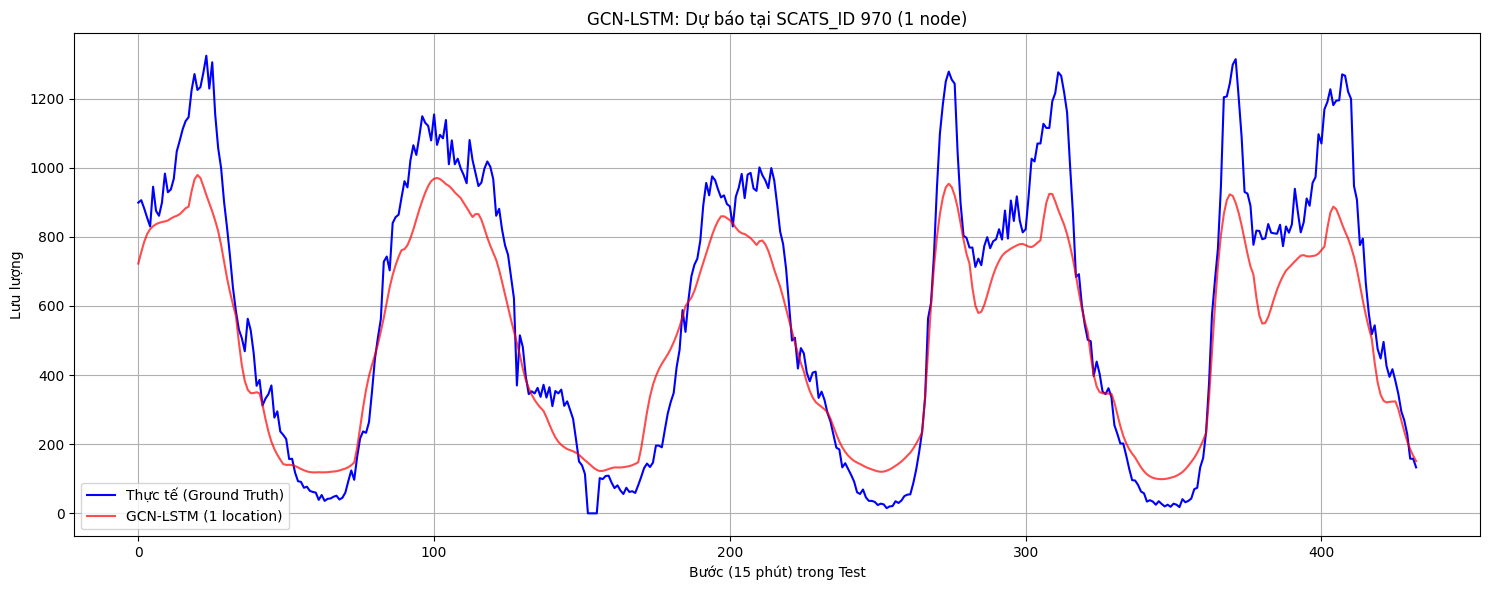

In [81]:
print("\n10. Evaluation với Test Set & Forecasting Visualization...")
model.eval()
with torch.no_grad():
        test_pred_scaled = model(
            torch.tensor(X_test, dtype=torch.float32).to(device),
            target_idx=target_node_idx,
        ).cpu().numpy()  # (samples,)

y_test_target_scaled = y_test[:, target_node_idx]  # (samples,)

y_test_denorm = scaler_y.inverse_transform(y_test_target_scaled.reshape(-1, 1)).flatten()
test_pred_denorm = scaler_y.inverse_transform(test_pred_scaled.reshape(-1, 1)).flatten()

test_mse = np.mean((y_test_denorm - test_pred_denorm) ** 2)
test_rmse = np.sqrt(test_mse)
print(f"   => Test MSE (thang đo gốc — xe/15 phút) @ node {target_node_idx}: {test_mse:.4f}")
print(f"   => Test RMSE (thang đo gốc — xe/15 phút) @ node {target_node_idx}: {test_rmse:.4f}")

nodes_list = list(node_to_idx.keys())
node_id = nodes_list[target_node_idx]

plt.figure(figsize=(15, 6))
plt.plot(y_test_denorm[:500], label="Thực tế (Ground Truth)", color="blue")
plt.plot(test_pred_denorm[:500], label="GCN-LSTM (1 location)", color="red", alpha=0.7)
plt.title(f"GCN-LSTM: Dự báo tại SCATS_ID {node_id} (1 node)")
plt.xlabel("Bước (15 phút) trong Test")
plt.ylabel("Lưu lượng")
plt.legend()
plt.grid()
plt.tight_layout()
plt.show()

In [ ]:
torch.save(model.state_dict(), '../models/custom_gcn_lstm/custom_gcn_lstm_model.pth')
print("Custom GCN-LSTM model saved successfully!")

Custom GCN-LSTM model saved successfully!


: 